In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 1. Carregar o dataset
srp = pd.read_csv("./DATASET/survey_results_public.csv")

# 2. Lista de valores inválidos
valores_invalidos = ['?', 'n.a', 'n.a.', 'NA', 'na', 'N/A']

# 3. Substituir esses valores por NaN
srp = srp.replace(valores_invalidos, np.nan)

# 4. Criar 3 cópias do dataset original
dataset_media = srp.copy()
dataset_mediana = srp.copy()
dataset_zero = srp.copy()

# 5. Selecionar apenas colunas numéricas
colunas_numericas = srp.select_dtypes(include=[np.number]).columns

# 6. Preencher valores em falta nas colunas numéricas
for col in colunas_numericas:
    dataset_media[col] = dataset_media[col].fillna(dataset_media[col].mean())
    dataset_mediana[col] = dataset_mediana[col].fillna(dataset_mediana[col].median())
    dataset_zero[col] = dataset_zero[col].fillna(0)

# 7. Se quiseres também tratar colunas de texto, podes preencher com "Sem dado"
colunas_texto = srp.select_dtypes(include=["object"]).columns

for col in colunas_texto:
    dataset_media[col] = dataset_media[col].fillna("Sem dado")
    dataset_mediana[col] = dataset_mediana[col].fillna("Sem dado")
    dataset_zero[col] = dataset_zero[col].fillna("Sem dado")

# 8. Guardar os 3 novos datasets em ficheiros CSV
dataset_media.to_csv("./DATASET/dataset_limpo_media.csv", index=False)
dataset_mediana.to_csv("./DATASET/dataset_limpo_mediana.csv", index=False)
dataset_zero.to_csv("./DATASET/dataset_limpo_zero.csv", index=False)

print("Os 3 ficheiros foram criados com sucesso na pasta DATASET.")

Os 3 ficheiros foram criados com sucesso na pasta DATASET.


In [3]:
dataset_media.isna().sum()

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

In [4]:
dataset_mediana.isna().sum()

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

In [5]:
dataset_zero.isna().sum()

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

In [6]:
dataset_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [7]:
dataset_mediana.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [8]:
dataset_media.compare(dataset_mediana)

CompTotal              WorkExp       JobSatPoints_1        \
                self     other       self other           self other   
0      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
1      2.963841e+145  110000.0        NaN   NaN            NaN   NaN   
2      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
3      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
4      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
...              ...       ...        ...   ...            ...   ...   
65432  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
65433  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
65434  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
65435  2.963841e+145  110000.0        NaN   NaN            NaN   NaN   
65436  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   

      JobSatPoints_4       JobSatPoints_5        ... JobSatPoints_9        \
                self other           self other  ...           self other   
0            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
1                NaN   NaN            NaN   NaN  ...            NaN   NaN   
2            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
3            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
4            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
...              ...   ...            ...   ...  ...            ...   ...   
65432        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
65433        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
65434        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
65435            NaN   NaN            NaN   NaN  ...            NaN   NaN   
65436        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   

      JobSatPoints_10       JobSatPoints_11       ConvertedCompYearly  \
                 self other            self other                self   
0           10.955713   0.0        9.953948   0.0        86155.287263   
1                 NaN   NaN             NaN   NaN        86155.287263   
2           10.955713   0.0        9.953948   0.0        86155.287263   
3           10.955713   0.0        9.953948   0.0        86155.287263   
4           10.955713   0.0        9.953948   0.0        86155.287263   
...               ...   ...             ...   ...                 ...   
65432       10.955713   0.0        9.953948   0.0        86155.287263   
65433       10.955713   0.0        9.953948   0.0        86155.287263   
65434       10.955713   0.0        9.953948   0.0        86155.287263   
65435             NaN   NaN             NaN   NaN        86155.287263   
65436       10.955713   0.0        9.953948   0.0        86155.287263   

                  JobSat        
         other      self other  
0      65000.0  6.935041   7.0  
1      65000.0  6.935041   7.0  
2      65000.0  6.935041   7.0  
3      65000.0  6.935041   7.0  
4      65000.0  6.935041   7.0  
...        ...       ...   ...  
65432  65000.0  6.935041   7.0  
65433  65000.0  6.935041   7.0  
65434  65000.0  6.935041   7.0  
65435  65000.0  6.935041   7.0  
65436  65000.0  6.935041   7.0  

[49642 rows x 26 columns]

In [9]:
dataset_media.isna().sum().sum()

np.int64(0)

In [10]:
dataset_mediana.isna().sum().sum()

np.int64(0)

In [11]:
dataset_media.isna().sum().sort_values(ascending=False)

ResponseId                0
Knowledge_4               0
Knowledge_2               0
Knowledge_1               0
WorkExp                   0
                         ..
EmbeddedHaveWorkedWith    0
WebframeAdmired           0
WebframeWantToWorkWith    0
WebframeHaveWorkedWith    0
JobSat                    0
Length: 114, dtype: int64

In [12]:
# 1. Carregar o dataset limpo (com zero)
srp = pd.read_csv("./DATASET/survey_results_public.csv")
#LIMPEZA: Transformar o texto em intervalos simples
# Removemos "years old", "Under", etc.
srp['Age'] = (srp['Age']
             .str.replace(' years old', '', regex=False)
             .str.replace('Under ', '<', regex=False)
             .str.replace(' years or older', '+', regex=False))

In [13]:
# CRIAR A VARIÁVEL NUMÉRICA DE GAMAS (Age_Code)
# A professora sugeriu isto para que a variável seja tratada como um "valor"
# Atribuímos um peso de 1 a 7 para cada faixa etária
map_num = {
    '<18': 1, 
    '18-24': 2, 
    '25-34': 3, 
    '35-44': 4, 
    '45-54': 5, 
    '55-64': 6, 
    '65+': 7,
    'Prefer not to say': 0  # Atribuímos 0 para quem não quis dizer
}
srp['Age_Code'] = srp['Age'].map(map_num)
srp['Age_Code'] = srp['Age_Code'].astype(int)

In [14]:
# CRIAÇÃO DA VARIÁVEL DE GERAÇÕES (Variável qualitativa)
map_gen = {
    '<18': 'Gen Alpha', 
    '18-24': 'Gen Z', 
    '25-34': 'Millennials', 
    '35-44': 'Millennials/Gen X', 
    '45-54': 'Gen X', 
    '55-64': 'Boomers', 
    '65+': 'Silent Generation',
    'Prefer not to say': 'Não Declarado'
}
srp['Geração'] = srp['Age'].map(map_gen)

In [15]:
# VERIFICAÇÃO
print("Novas variáveis criadas com sucesso:")
print(srp[['Age', 'Age_Code', 'Geração']].head(10))

Novas variáveis criadas com sucesso:
     Age  Age_Code            Geração
0    <18         1          Gen Alpha
1  35-44         4  Millennials/Gen X
2  45-54         5              Gen X
3  18-24         2              Gen Z
4  18-24         2              Gen Z
5    <18         1          Gen Alpha
6  35-44         4  Millennials/Gen X
7  18-24         2              Gen Z
8  45-54         5              Gen X
9  35-44         4  Millennials/Gen X


In [16]:
# Mostrar a contagem de nulos em todas as colunas (foi apenas uma validação para garantir que não há mais nulos)
print(srp.isnull().sum())

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Age_Code                   0
Geração                    0
Length: 116, dtype: int64


In [17]:
#SALVAR NUMA NOVA CÓPIA (Juntei o meu trabalho com o dataset limpo zero do Luís)
srp.to_csv('DATASET/dataset_limpo_mg.csv', index=False)

In [18]:
srp.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'SurveyLength', 'SurveyEase', 'ConvertedCompYearly',
       'JobSat', 'Age_Code', 'Geração'],
      dtype='object', length=116)

/var/folders/_g/8m1r5bhd5811c2pcdtcbq_3h0000gn/T/ipykernel_1700/1305089303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Geração', y='ConvertedCompYearly', palette='Set2')


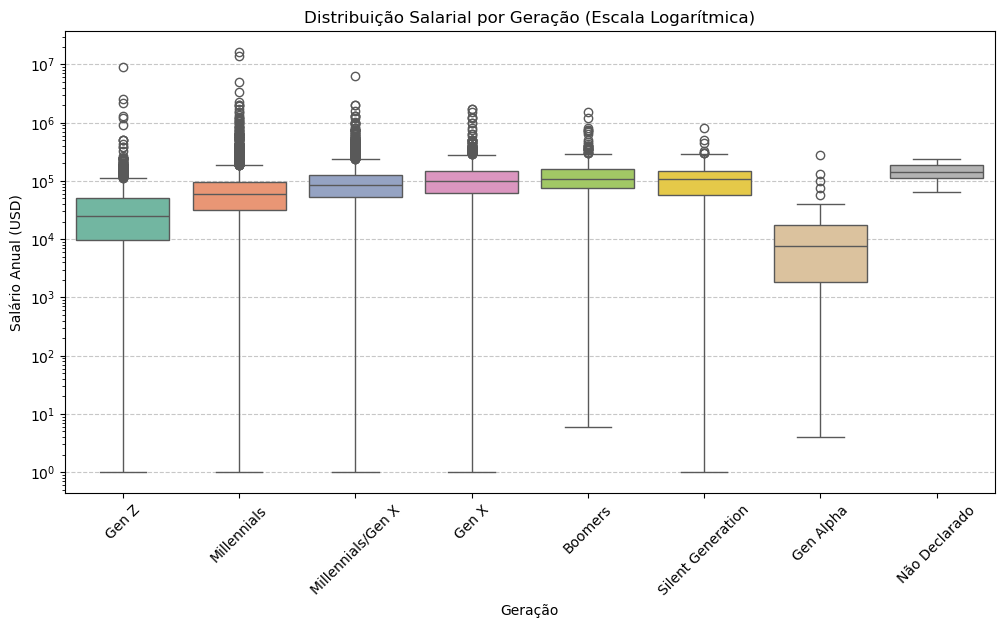

In [19]:
# 1. Filtrar o dataset para excluir salários zero ou nulos (para o gráfico não ficar distorcido)
df_plot = srp[srp['ConvertedCompYearly'] > 0]

# 2. Criar o gráfico
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Geração', y='ConvertedCompYearly', palette='Set2')

# 3. Ajustar escala (salários podem ter valores muito altos, o log scale ajuda a ver melhor)
plt.yscale('log') 

plt.title('Distribuição Salarial por Geração (Escala Logarítmica)')
plt.xlabel('Geração')
plt.ylabel('Salário Anual (USD)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.show()

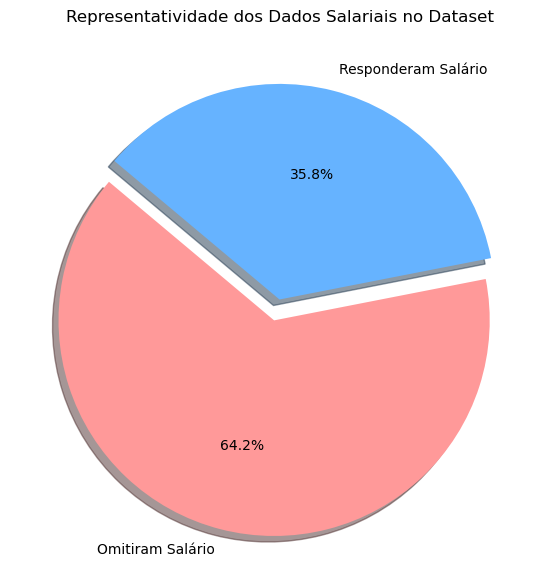

Total de respostas: 65437
Pessoas que não declararam salário: 42002 (64.2%)
Pessoas que declararam salário: 23435 (35.8%)


In [20]:

# 1. Total de registros
total = len(srp)

# 2. Corrigindo a contagem: pegamos os Nulos (NaN) OU os que são 0/negativos
# O símbolo | significa "OU" em lógica de Pandas
sem_salario = srp[srp['ConvertedCompYearly'].isna() | (srp['ConvertedCompYearly'] <= 0)].shape[0]

# 3. O restante é quem respondeu com um valor válido
com_salario = total - sem_salario

# Dados para o gráfico
labels = ['Omitiram Salário', 'Responderam Salário']
sizes = [sem_salario, com_salario]
colors = ['#ff9999', '#66b3ff']

# Criar o gráfico
plt.figure(figsize=(7, 7))
# Adicionei o shadow=True e startangle=140 para ficar mais profissional
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0), shadow=True)
plt.title('Representatividade dos Dados Salariais no Dataset')
plt.show()

print(f"Total de respostas: {total}")
print(f"Pessoas que não declararam salário: {sem_salario} ({(sem_salario/total)*100:.1f}%)")
print(f"Pessoas que declararam salário: {com_salario} ({(com_salario/total)*100:.1f}%)")

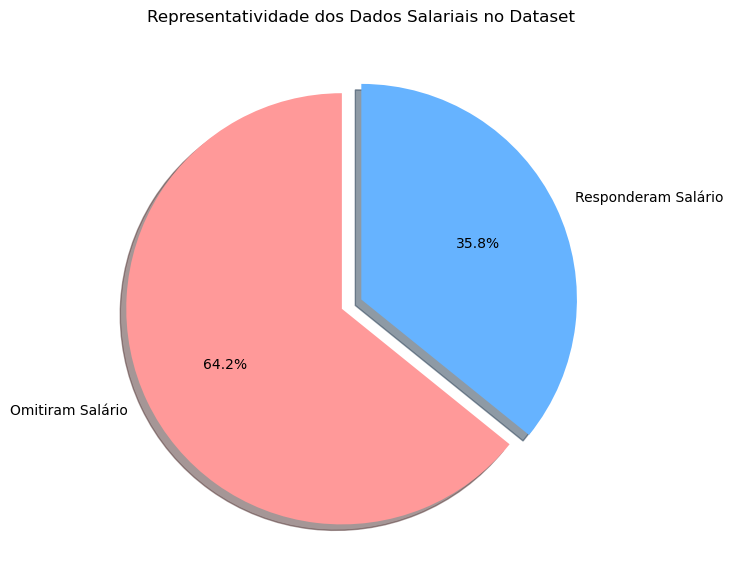

Total de respostas no CSV: 65437
Pessoas que deixaram o salário em branco: 42002


In [21]:
import matplotlib.pyplot as plt

# 1. Contar quem realmente não respondeu (Valores Nulos/NaN)
total = len(srp)
sem_salario = srp['ConvertedCompYearly'].isna().sum() 
com_salario = total - sem_salario

# 2. Dados para o gráfico
labels = ['Omitiram Salário', 'Responderam Salário']
sizes = [sem_salario, com_salario]
colors = ['#ff9999','#66b3ff']

# 3. Criar o Pie Plot (Conforme PDF 8 da Stora, pág 3 - "Compare parts of a whole")
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=colors, explode=(0.1, 0), shadow=True)

plt.title('Representatividade dos Dados Salariais no Dataset')
plt.show()

print(f"Total de respostas no CSV: {total}")
print(f"Pessoas que deixaram o salário em branco: {sem_salario}")

In [22]:
# Calcula a correlação de Pearson entre o código da idade e o salário
# Usamos apenas os valores onde o salário é maior que 0
df_stats = srp[srp['ConvertedCompYearly'] > 0]
corr = df_stats['Age_Code'].corr(df_stats['ConvertedCompYearly'])
print(f"O coeficiente de correlação de Pearson é: {corr:.3f}")

O coeficiente de correlação de Pearson é: 0.123


In [23]:
# Isto cria o ranking exato com valores
ranking = df_plot.groupby('Geração')['ConvertedCompYearly'].median().sort_values(ascending=False)
print(ranking)


Geração
Não Declarado        140000.0
Boomers              109691.0
Silent Generation    106000.0
Gen X                 99099.0
Millennials/Gen X     84796.0
Millennials           59825.0
Gen Z                 25000.0
Gen Alpha              7626.5
Name: ConvertedCompYearly, dtype: float64


In [24]:
# Lista das gerações que queres comparar
geracoes_alvo = ['Gen Z', 'Gen X', 'Boomers']

for gen in geracoes_alvo:
    df_gen = srp[srp['Geração'] == gen]
    total = len(df_gen)
    omissao = df_gen[df_gen['ConvertedCompYearly'] <= 0].shape[0]
    perc = (omissao / total) * 100
    
    print(f"--- {gen} ---")
    print(f"Total: {total} | Omissão: {omissao} | Perc: {perc:.1f}%")

    restantes_geracoes = ['Millennials', 'Millennials/Gen X', 'Silent Generation', 'Gen Alpha']

for gen in restantes_geracoes:
    df_gen = srp[srp['Geração'] == gen]
    total = len(df_gen)
    omissao = df_gen[df_gen['ConvertedCompYearly'] <= 0].shape[0]
    perc = (omissao / total) * 100 if total > 0 else 0
    
    print(f"--- {gen} ---")
    print(f"Total: {total} | Omissão: {omissao} | Perc: {perc:.1f}%")

--- Gen Z ---
Total: 14098 | Omissão: 0 | Perc: 0.0%
--- Gen X ---
Total: 6249 | Omissão: 0 | Perc: 0.0%
--- Boomers ---
Total: 2575 | Omissão: 0 | Perc: 0.0%
--- Millennials ---
Total: 23911 | Omissão: 0 | Perc: 0.0%
--- Millennials/Gen X ---
Total: 14942 | Omissão: 0 | Perc: 0.0%
--- Silent Generation ---
Total: 772 | Omissão: 0 | Perc: 0.0%
--- Gen Alpha ---
Total: 2568 | Omissão: 0 | Perc: 0.0%


In [25]:
# Filtrar apenas quem declarou salário (> 0)
df_valid = srp[srp['ConvertedCompYearly'] > 0]

# Calcular Mediana, Média e Contagem de quem sobrou
ranking_real = df_valid.groupby('Geração')['ConvertedCompYearly'].agg(['median', 'mean', 'count']).sort_values(by='median', ascending=False)

# Formatar para ficar legível (Moeda)
pd.options.display.float_format = '{:,.2f}'.format

print("--- RANKING SALARIAL REAL (Apenas quem respondeu) ---")
print(ranking_real)

--- RANKING SALARIAL REAL (Apenas quem respondeu) ---
                      median       mean  count
Geração                                       
Não Declarado     140,000.00 145,458.22      9
Boomers           109,691.00 129,865.48    863
Silent Generation 106,000.00 123,561.59    137
Gen X              99,099.00 116,944.49   2329
Millennials/Gen X  84,796.00 104,450.16   6231
Millennials        59,825.00  79,120.56  10369
Gen Z              25,000.00  41,919.51   3433
Gen Alpha           7,626.50  19,294.08     64


In [26]:


# Configura o Pandas para mostrar TODAS as colunas (None significa sem limite)
pd.set_option('display.max_columns', None)

# Se quiseres ver os nomes das colunas como uma lista limpa
print(list(srp.columns))

# Ou, para veres o formato, tipo de dados e se há nulos de cada uma:
# df.info(verbose=True, show_counts=True)

['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

In [27]:
# 3. Ver as primeiras 10 linhas
print("\nPrimeiras 10 linhas:")
print(srp['YearsCodePro'].head(10))


Primeiras 10 linhas:
0    NaN
1     17
2     27
3    NaN
4    NaN
5    NaN
6      7
7    NaN
8    NaN
9     11
Name: YearsCodePro, dtype: object


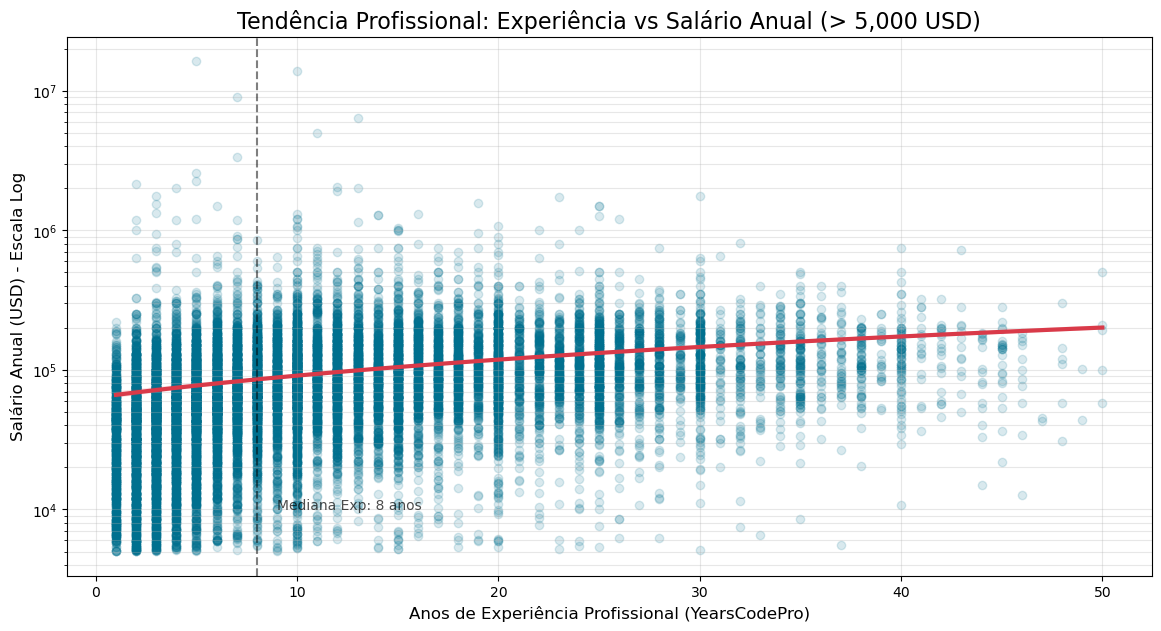

In [28]:
# 1. Preparar os dados (Limpar 'YearsCodePro' e 'ConvertedCompYearly')
# errors='coerce' transforma o "Sem dado" em vazio (NaN)
temp_df = srp.copy()
temp_df['YearsCodePro'] = pd.to_numeric(temp_df['YearsCodePro'], errors='coerce')

# 2. Filtrar o Lixo Salarial e Experiência Nula
# Vamos considerar apenas salários > 5.000 USD e experiência <= 50 anos para clareza
min_salario = 5000
temp_df = temp_df[(temp_df['ConvertedCompYearly'] > min_salario) & 
                   (temp_df['YearsCodePro'].notnull()) &
                   (temp_df['YearsCodePro'] <= 50)]

# 3. Criar o Gráfico de Dispersão Limpo
plt.figure(figsize=(14, 7))

# Usar 'sns.regplot' que já coloca a linha de tendência (2.5% feature visual)
# alpha=0.15 torna os pontos muito transparentes para ver densidade
sns.regplot(data=temp_df, x='YearsCodePro', y='ConvertedCompYearly',
            scatter_kws={'alpha': 0.15, 'color': '#00708f'}, # Pontos transparentes
            line_kws={'color': '#d93a49', 'linewidth': 3})    # Linha de tendência vermelha

# 4. Ajustes Visuais Profissionais
plt.yscale('log') # Escala logarítmica ainda é necessária
plt.title(f'Tendência Profissional: Experiência vs Salário Anual (> {min_salario:,.0f} USD)', fontsize=16)
plt.xlabel('Anos de Experiência Profissional (YearsCodePro)', fontsize=12)
plt.ylabel('Salário Anual (USD) - Escala Log', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)

# Mostrar a mediana de experiência só para contextualizar (5% estatística)
median_exp = temp_df['YearsCodePro'].median()
plt.axvline(median_exp, color='black', linestyle='--', alpha=0.5)
plt.text(median_exp+1, min_salario*2, f'Mediana Exp: {median_exp:.0f} anos', color='black', alpha=0.7)

plt.show()

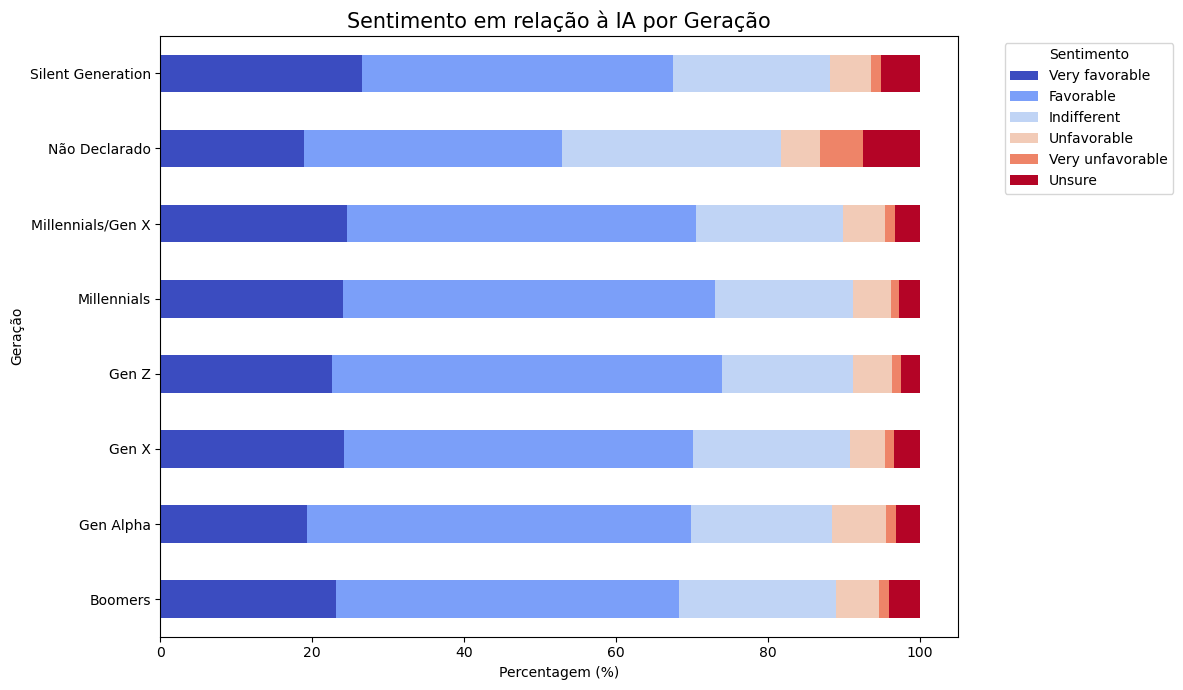

In [29]:
# O gráfico de dispersão mostra claramente a tendência de aumento salarial com mais anos de experiência, mas também evidencia a grande variação salarial em cada nível de experiência, o que é comum em dados salariais. A linha de tendência ajuda a visualizar essa relação geral, enquanto os pontos transparentes mostram a densidade dos dados.
# 1. Limpar dados: Remover quem não respondeu ao sentimento da IA
df_ai = srp[srp['AISent'].notnull()].copy()

# 2. Criar uma tabela de cruzamento (Geração vs Sentimento)
# normalize='index' transforma em percentagem para podermos comparar grupos de tamanhos diferentes
ai_analysis = pd.crosstab(df_ai['Geração'], df_ai['AISent'], normalize='index') * 100

# 3. Ordenar as colunas de sentimento para fazerem sentido lógico
ordem_sentimento = ['Very favorable', 'Favorable', 'Indifferent', 'Unfavorable', 'Very unfavorable', 'Unsure']
ai_analysis = ai_analysis.reindex(columns=ordem_sentimento)

# 4. Desenhar o gráfico
ai_analysis.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='coolwarm')

plt.title('Sentimento em relação à IA por Geração', fontsize=15)
plt.xlabel('Percentagem (%)')
plt.ylabel('Geração')
plt.legend(title='Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [30]:
# O gráfico de barras horizontais empilhadas mostra claramente as diferenças de sentimento em relação à IA entre as gerações. As gerações mais jovens (Gen Z e Millennials) tendem a ter sentimentos mais favoráveis, enquanto as gerações mais velhas (Boomers e Silent Generation) mostram uma maior proporção de sentimentos desfavoráveis. A geração "Gen Alpha" tem uma distribuição mais equilibrada, mas isso pode ser devido ao número menor de respondentes nessa faixa etária. A legenda e os rótulos ajudam a interpretar facilmente as diferenças entre os grupos.
# 1. Percentagem de Uso de IA por Geração (Coluna AISelect)
uso_ia = pd.crosstab(srp['Geração'], srp['AISelect'], normalize='index') * 100

# 2. Confiança média na IA (AIAcc - Transformar escala de texto em número)
confianca_map = {
    'Highly trust': 5,
    'Trust': 4,
    'Neither trust nor distrust': 3,
    'Distrust': 2,
    'Highly distrust': 1
}
srp['AI_Trust_Score'] = srp['AIAcc'].map(confianca_map)
confianca_gen = srp.groupby('Geração')['AI_Trust_Score'].mean()

print("--- Percentagem de Uso de IA ---")
print(uso_ia)
print("\n--- Média de Confiança (1-5) ---")
print(confianca_gen)

--- Percentagem de Uso de IA ---
AISelect           No, and I don't plan to  No, but I plan to soon   Yes
Geração                                                                 
Boomers                              36.98                   22.13 40.89
Gen Alpha                            29.37                    9.93 60.69
Gen X                                27.99                   19.39 52.62
Gen Z                                20.85                    8.75 70.40
Millennials                          21.47                   12.96 65.57
Millennials/Gen X                    25.91                   16.14 57.94
Não Declarado                        41.88                   13.72 44.40
Silent Generation                    47.31                   20.43 32.26

--- Média de Confiança (1-5) ---
Geração
Boomers             2.72
Gen Alpha           2.83
Gen X               2.78
Gen Z               2.75
Millennials         2.73
Millennials/Gen X   2.64
Não Declarado       2.45
Silent Generation   

In [31]:
# Isto mostra-te TODAS as variações de texto que as pessoas escreveram, 
# ordenadas pelas que mais aparecem. 
# Isto obriga o Python a imprimir TODAS as linhas do value_counts
with pd.option_context('display.max_rows', None):
    print(srp['YearsCodePro'].value_counts())

YearsCodePro
2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12                    1777
15                    1635
20                    1549
9                     1493
11                    1312
13                    1127
14                    1082
25                     998
16                     946
18                     867
17                     814
30                     689
24                     632
19                     516
22                     492
23                     448
26                     426
21                     380
27                     380
28                     342
35                     285
29                     196
40                     194
32                     194
34                     169
38                     134
33             